# Initialization

In [1]:
COUNTRIES = [
'AU', 'AT', 'BE', 'CA', 'CZ', 'DK', 'FI', 'FR', 'DE', 'GB', 
'IT', 'JP', 'NL', 'PL', 'PT', 'SK', 'ES', 'SE', 'CH', 'US']

In [2]:
!python --version
!pip install -r requirements.txt --disable-pip-version-check | tail -n 5

Python 3.12.8


In [3]:
import json,sys

import numpy as np
import pandas as pd
import geopandas as gpd
import shapely as sh
import matplotlib.pyplot as plt

import folium
from folium.plugins import MarkerCluster
from IPython.display import HTML,Image

from requests_ratelimiter import LimiterSession
session = LimiterSession(per_second=1)
session.headers.update({'User-Agent': 'safeweb','email':'komosny@vut.cz'})

from tqdm import tqdm
tqdm.pandas(file=sys.stdout,ncols=100)

from joblib import Memory
memory = Memory(location=f'__cache',verbose=0)

# Functions

In [4]:
@memory.cache
def REST_API_GET(url):

    result = pd.NA
    
    try:        
        result = session.get(url=url)
    except:
        print('REST API connection error.')
        raise SystemExit
    
    return result

In [5]:
def parse_website(url):

    result = pd.NA

    # wrong openstreetmap records
    url = url.replace('"','')
    url = url.split(';')[0]
    
    url = url.removeprefix('https://')
    url = url.removeprefix('http://')

    website = url.split('/')[0]

    # verify
    test = website.replace('.','').replace('-','')

    if test.isalnum() and not test.isnumeric():
    
        websites = website.split('.')[-3:]

        # not too long
        if len(websites[0]) < 20:
            
            # drop possible empty parts
            websites = [item for item in websites if item]
    
            if len(websites) > 1:
                website = '.'.join(websites)
                result = website
    
    return result

In [6]:
def country_to_area(country):
    
    area_id = pd.NA

    url = f'https://nominatim.openstreetmap.org/search?country={country}&format=json'
    
    response = REST_API_GET(url)
    
    if pd.notna(response) and response.status_code == 200:
        
        try:
            response_data = json.loads(response.text)
            
            # find first relation record
            for record in response_data:    
                if record['osm_type'] == 'relation':
                    area_id = record['osm_id'] + 3600000000; break
        except:
            print('REST API data error.')
            raise SystemExit
            
    else:      
        print('REST API request error.')
        raise SystemExit

    return area_id

In [7]:
def get_country_urls(area):

    urls = []

    query = f'''[out:json][timeout:1200];
    area({area}) -> .country;
    (
      nw['website'](area.country);
    );
    out center;'''
    
    #url = f'https://overpass-api.de/api/interpreter?data={query}'
    url = f'https://overpass.kumi.systems/api/interpreter?data={query}'
    
    response = REST_API_GET(url)
    
    if pd.notna(response) and response.status_code == 200:
        try:
            response_data = response.json()['elements']

            for item in response_data:
                if item['type'] == 'node': 
                    urls.append(['node',item['tags']['website'],item['lat'],item['lon'],item['tags']])
                else:
                    urls.append(['way',item['tags']['website'],item['center']['lat'],item['center']['lon'],item['tags']])
                    
        except:
            print('REST API data error.')
            raise SystemExit
    else:
        print('REST API request error.')
        raise SystemExit
   
    if len(urls) == 0: urls = pd.NA

    return urls

In [8]:
facility_type = {
'animal_boarding', 'animal_breeding', 'animal_shelter', 'animal_training',
'archive', 'art_gallery', 'art_school', 'arts_centre', 'baby_hatch', 'bar',
'bbq', 'bench', 'bicycle_library', 'bicycle_parking', 'bicycle_rental',
'bicycle_repair_station', 'bicycle_wash', 'biergarten', 'blood_bank',
'boat_rental', 'boat_sharing', 'boat_storage', 'bus_station', 'cafe',
'canteen', 'car_rental', 'car_sharing', 'car_wash', 'charging_station',
'childcare', 'cinema', 'clinic', 'clock', 'clubhouse', 'college',
'community_centre', 'compressed_air', 'concert_hall', 'conference_centre',
'construction', 'cooking_school', 'courthouse', 'coworking_space',
'crematorium', 'customs', 'dancing_school', 'dentist',
'device_charging_station', 'dive_centre', 'doctors', 'dog_training', 'dojo',
'dormitory', 'drinking_water', 'driver_training', 'driving_school',
'embassy', 'events_centre', 'events_venue', 'exhibition_centre',
'facility_building', 'fast_food', 'ferry_terminal', 'festival_grounds',
'fire_station', 'first_aid_school', 'flight_school', 'food_court',
'food_sharing', 'fountain', 'fraternity', 'fuel', 'funeral_hall',
'funeral_home', 'give_box', 'goverment', 'grave_yard', 'grit_bin', 'gym',
'healthcare', 'hospital', 'hotel', 'ice_cream', 'information',
'internet_cafe', 'karaoke_box', 'kindergarten', 'kitchen', 'language_school',
'library', 'lifeboat', 'lifeboat_station', 'luggage_locker',
'mobile_library', 'mobility_hub', 'monastery', 'mortuary', 'mountain_rescue',
'museum', 'music_school', 'music_venue', 'nursing_home', 'parish_hall',
'park', 'parking', 'parking_entrance', 'parking_space', 'personal_service',
'pharmacy', 'photo_booth', 'place_of_mourning', 'place_of_worship',
'planetarium', 'playground', 'police', 'polling_station', 'post_box',
'post_depot', 'post_office', 'prep_school', 'prison', 'pub', 'public_bath',
'public_bookcase', 'public_building', 'ranger_station', 'reception_area',
'reception_desk', 'recycling', 'research', 'research_institute',
'restaurant', 'retirement_home', 'sailing_school', 'sanitary_dump_station',
'school', 'scooter_rental', 'scout_hall', 'scout_hut', 'shelter', 'shower',
'ski_rental','ski_school', 'small_electric_vehicle_parking', 'social_centre',
'social_club', 'social_facility', 'spa', 'sports_centre', 'stables',
'stadium', 'stage', 'student_accommodation', 'studio', 'study_room',
'subway_entrance', 'surf_school', 'swimming_pool', 'taxi', 'telephone', 'theatre',
'toilets', 'tool_library', 'tourism', 'townhall', 'toy_library', 'trade_school',
'traffic_park', 'training', 'university', 'vehicle_inspection',
'vending_machine', 'veterinary', 'waste_basket', 'waste_disposal',
'waste_transfer_station', 'weighbridge'}

commerce_type = {
'money_transfer', 'insurance', 'parcel_locker', 'locker', 'office', 'shop',
'clothes', 'payment_terminal', 'workshop', 'hobby_shop', 'financial_advice',
'supermarket', 'convenience', 'marketplace', 'mall', 'bank', 'atm',
'bureau_de_change', 'motorcycle_rental'} 

forbidden_type = {
'swingerclub', 'casino', 'nightclub', 'gambling', 'love_hotel',
'hookah_lounge', 'brothel', 'car_pooling', 'stripclub', 'prostitution',
'erotic', 'adult_gaming_centre', 'sexshop'}

facility_dict = {key:'Facility' for key in facility_type}
commerce_dict = {key:'Commerce' for key in commerce_type}
forbidden_dict = {key:'Forbidden' for key in forbidden_type}
amenity_types = {**facility_dict,**commerce_dict,**forbidden_dict}

In [9]:
def get_place_type(tags):

    result = pd.NA

    amenity = tags.get('amenity',pd.NA)
    
    if amenity is not pd.NA:
        result = amenity_types.get(amenity.lower(),pd.NA)
    
    if result is pd.NA:
        result = 'Unknown'
    
        if any(key in tags for key in ['shop','company','craft','brand']):
            result = 'Commerce'    
        
        if any(key in tags for key in ['aerialway','aeroway','attraction', 'boundary', 'camera', 'cemetery',
                                       'club', 'cuisine', 'crop','emergency','ferry', 'fuel', 'from',
                                       'healthcare', 'highway', 'historic','industrial','leisure', 'man_made',
                                       'military', 'natural','office', 'parking','population','public_transport',
                                       'railway', 'road', 'route', 'sport','telecom','tourism']):
            result = 'Facility'

        if any(key in tags for key in ['adult_gaming_centre', 'brothel', 'casino', 'erotic', 'gambling',
                                       'hookah', 'love', 'nightclub', 'prostitution', 'sexshop',
                                       'stripclub', 'swingerclub']):
            result = 'Forbidden'
    
    return result

In [10]:
def frame_info(frame,mem=False,dtype=False,sample=False,n=5,width=50,columns=50):

    size = len(frame)

    if mem: 
        print(round(frame.memory_usage(deep=True)/(1024**3),1).to_string())
        print('Total ',round(frame.memory_usage(deep=True).sum()/(1024**3),1))

    if dtype:
        print()
        print(frame.dtypes.to_string())     

    if sample:
        frame = frame.sample(min(n,size))

    with pd.option_context('display.min_rows', n, 'display.max_rows', n,
                           'display.max_columns', columns,'display.max_colwidth', width):
        display(frame)

    return

# Main

In [11]:
data = pd.DataFrame(COUNTRIES,columns = ['country'])
data.country = data.country.astype('category')

data['area'] = data.country.progress_apply(country_to_area)
data.area = data.area.astype('category')

data['urls'] = data.progress_apply(lambda r: get_country_urls(r.area),axis=1)
data.pop('area')

data = data.explode('urls',ignore_index=True).rename(columns = {'urls':'url'})
data[['osm','url','lat','lon','tags']] = pd.DataFrame(data.url.tolist(), index=data.index)

data.osm = data.osm.astype('category')
data.url = data.url.str.lower()
data.url = data.url.astype(pd.StringDtype('pyarrow'))
data.lat = data.lat.astype(pd.StringDtype('pyarrow'))
data.lon = data.lon.astype(pd.StringDtype('pyarrow'))

data = data.sample(frac=1)

frame_info(data,dtype=True)

100%|███████████████████████████████████████████████████████████████| 20/20 [00:13<00:00,  1.45it/s]

country           category
url        string[pyarrow]
osm               category
lat        string[pyarrow]
lon        string[pyarrow]
tags                object


,country,url,osm,lat,lon,tags
706743,DE,https://www.madebyrons.de/,node,51.0639209,13.7484667,"{'addr:city': 'Dresden', 'addr:housenumber': '..."
2568445,US,http://www.bidarkainn.com,way,59.6420498,-151.5577235,"{'addr:city': 'Homer', 'addr:housenumber': '57..."
...,...,...,...,...,...,...
2305984,US,https://www.starbucks.com/store-locator/store/...,node,42.7626012,-84.5005548,"{'addr:city': 'East Lansing', 'addr:housenumbe..."
1619900,JP,http://www.dreamsnet.com/,way,34.262904,135.109021,"{'building': 'yes', 'name': 'ドリーム産業', 'name:en..."


In [12]:
data['website'] = data.url.progress_apply(parse_website)
data.pop('url')
todrop = data.loc[data.website.isna()]
print(len(todrop))
data = data.drop(todrop.index)
data.website = data.website.astype(pd.StringDtype('pyarrow'))

global_social_shops = ['facebook.com','twitter.com','x.com','instagram.com','tiktok.com','snapchat.com','youtube.com',
                'amazon.com','ebay.com','aliexpress.com','walmart.com','target.com','temu.com','wish.com']
pattern = '|'.join(global_social_shops)

todrop = data.loc[data.website.str.contains(pattern)]
print(len(todrop))
data = data.drop(todrop.index)

frame_info(data,dtype=True)

100%|████████████████████████████████████████████████| 2916062/2916062 [00:02<00:00, 1132438.24it/s]
112935
46698

country           category
osm               category
lat        string[pyarrow]
lon        string[pyarrow]
tags                object
website    string[pyarrow]


,country,osm,lat,lon,tags,website
706743,DE,node,51.0639209,13.7484667,"{'addr:city': 'Dresden', 'addr:housenumber': '...",www.madebyrons.de
2568445,US,way,59.6420498,-151.5577235,"{'addr:city': 'Homer', 'addr:housenumber': '57...",www.bidarkainn.com
...,...,...,...,...,...,...
2305984,US,node,42.7626012,-84.5005548,"{'addr:city': 'East Lansing', 'addr:housenumbe...",www.starbucks.com
1619900,JP,way,34.262904,135.109021,"{'building': 'yes', 'name': 'ドリーム産業', 'name:en...",www.dreamsnet.com


In [13]:
data['place_type'] = data.tags.progress_apply(get_place_type)
data.place_type = data.place_type.astype('category')

frame_info(data,mem=True,sample=True,n=10)

100%|█████████████████████████████████████████████████| 2756429/2756429 [00:04<00:00, 671869.65it/s]
Index         0.0
country       0.0
osm           0.0
lat           0.0
lon           0.0
tags          1.0
website       0.1
place_type    0.0
Total  1.1


,country,osm,lat,lon,tags,website,place_type
1765960,PL,node,50.4424448,16.251762,"{'addr:city': 'Kudowa-Zdrój', 'addr:housenumbe...",scaliano.com.pl,Facility
2109830,CH,node,47.3524006,8.2768836,"{'addr:city': 'Wohlen (AG)', 'addr:housenumber...",www.wohlen.ch,Facility
1314109,GB,way,51.6256826,-0.0684982,"{'addr:city': 'London', 'addr:postcode': 'N9 9...",enfield.sch.uk,Facility
1288704,GB,node,55.1503519,-2.9968333,"{'name': 'Nevina', 'shop': 'interior_decoratio...",nevina.co.uk,Commerce
1069979,DE,way,47.9876264,7.8493915,"{'addr:city': 'Freiburg im Breisgau', 'addr:ho...",www.esg-fr.de,Unknown
1603974,JP,way,36.2345286,140.3550497,"{'addr:block_number': '1698', 'addr:city': '小美...",omitama.ibaraki.jp,Facility
2056069,SE,node,56.0423744,14.1620532,"{'artist_name': 'Stig Blomberg', 'artwork_type...",www.kristianstad.se,Facility
1319244,GB,way,53.3517831,-2.6622166,"{'addr:city': 'Runcorn', 'addr:housenumber': '...",swi.co.uk,Unknown
2096240,CH,node,47.5087786,8.7069888,"{'craft': 'engraver', 'name': 'Bolliger Gravur...",www.bolliger-gravuren.ch,Commerce
1926835,SK,node,48.2224988,18.5971982,"{'name': 'Auto Aladin', 'shop': 'car', 'websit...",www.autoaladin.eu,Commerce


# Tests

In [14]:
data.loc[data.website.isna()]

,country,osm,lat,lon,tags,website,place_type


In [15]:
data.loc[data.lat.isna()]

,country,osm,lat,lon,tags,website,place_type


In [16]:
data.loc[data.place_type.isna()]

,country,osm,lat,lon,tags,website,place_type


# Reports

In [17]:
len(data.drop_duplicates(subset=['lat', 'lon']))

2754823

In [18]:
data.place_type.value_counts()

place_type
Facility     1842922
Commerce      731080
Unknown       176341
Forbidden       6086
Name: count, dtype: int64

In [19]:
data.loc[data.place_type == 'Facility'].sample(10)

,country,osm,lat,lon,tags,website,place_type
2729501,US,way,42.4905242,-83.1253683,"{'addr:city': 'Royal Oak', 'addr:housenumber':...",locations.tacobell.com,Facility
2068361,SE,way,59.3735105,18.0074623,"{'building': 'commercial', 'building:levels': ...",solnasimhall.se,Facility
371809,DK,node,55.2308357,11.755365,"{'amenity': 'bar', 'check_date': '2021-10-27',...",www.humlebar.dk,Facility
755358,DE,node,50.9928997,8.1080142,"{'historic': 'memorial', 'image': 'https://com...",www.stolpersteine.eu,Facility
1498274,IT,node,41.8933335,12.4765232,"{'addr:housenumber': '65', 'addr:postcode': '0...",www.orientalfonzie.com,Facility
2845839,US,way,40.4686308,-74.3044632,"{'addr:city': 'Parlin', 'addr:housenumber': '3...",arleth.sayrevillek12.net,Facility
2001827,ES,node,43.2479538,-5.7725219,"{'addr:housenumber': '10', 'addr:street': 'Cai...",www.alambiquegastrobar.es,Facility
1734808,NL,way,53.2231844,5.8221551,"{'leisure': 'pitch', 'name': 'K.V. Reitsje Him...",reitsjehim.nl,Facility
217179,CA,node,43.5962914,-79.7875403,"{'amenity': 'fast_food', 'cuisine': 'afghan', ...",www.pamierkabob.com,Facility
462146,FR,node,43.9450214,4.8137037,"{'addr:city': 'Avignon', 'addr:housenumber': '...",www.le-synopsis-restaurant-italien-avignon.com,Facility


In [20]:
data.loc[data.place_type == 'Commerce'].sample(10)

,country,osm,lat,lon,tags,website,place_type
1638300,NL,node,52.5040105,6.2598351,"{'addr:city': 'Dalfsen', 'addr:housenumber': '...",www.stegemanoptiek.nl,Commerce
1369870,GB,way,51.5095585,-0.1508373,"{'addr:housenumber': '96', 'addr:street': 'Mou...",www.marianorubinacci.it,Commerce
956091,DE,node,48.1743734,10.7668749,"{'addr:city': 'Schwabmünchen', 'addr:housenumb...",www.baywa.de,Commerce
1660174,NL,node,52.6547769,5.0825723,"{'addr:city': 'Hoorn', 'addr:housenumber': '53...",www.kapsalonirene.nl,Commerce
160623,BE,node,51.2173518,4.4182615,"{'entrance:kerb:height': '0', 'entrance:step_c...",www.slaets.eu,Commerce
2579201,US,way,38.9253858,-104.7762317,"{'addr:housenumber': '2785', 'addr:state': 'CO...",www.walgreens.com,Commerce
2651052,US,way,44.9628749,-92.983849,"{'brand': 'Walgreens', 'brand:wikidata': 'Q159...",www.walgreens.com,Commerce
863119,DE,node,50.0032717,8.2125138,"{'addr:postcode': '55124', 'email': 'foto-main...",www.foto-marschall.de,Commerce
1045177,DE,way,49.3365548,11.2918635,"{'addr:city': 'Schwarzenbruck', 'addr:housenum...",www.studio-coaching.de,Commerce
1243908,GB,node,52.4151658,-1.9706042,"{'addr:city': 'Birmingham', 'addr:housenumber'...",homebargains.co.uk,Commerce


In [21]:
data.loc[data.place_type == 'Unknown'].sample(10)

,country,osm,lat,lon,tags,website,place_type
1170845,DE,way,49.8504028,10.4628939,"{'addr:city': 'Ebrach', 'addr:country': 'DE', ...",www.baumwipfelpfad-ebrach.de,Unknown
2575415,US,way,42.3142695,-71.3420274,"{'addr:city': 'Natick', 'addr:housenumber': '1...",www.dacon1.com,Unknown
1977205,ES,node,28.6790432,-13.9414517,"{'addr:city': 'Lajarares', 'addr:housenumber':...",www.magma-kiteschool.com,Unknown
1134345,DE,way,50.2925592,7.6120537,"{'addr:city': 'Lahnstein', 'addr:housenumber':...",www.lahnsteiner.de,Unknown
1218721,DE,way,50.9349611,11.5900747,"{'check_date': '20204-09-09', 'construction': ...",www.dornburger-flats.de,Unknown
573329,FR,node,46.5504792,0.299913,"{'advertising': 'poster_box', 'animated': 'no'...",www.ellipse-affichage.com,Unknown
1161644,DE,way,50.8330379,6.468989,"{'addr:city': 'Düren', 'addr:country': 'DE', '...",www.korona-electric.de,Unknown
2577665,US,way,33.6953965,-112.0183339,"{'addr:city': 'Phoenix', 'addr:housenumber': '...",cem.va.gov,Unknown
2138203,CH,way,47.4787915,8.2062553,"{'addr:city': 'Brugg', 'addr:country': 'CH', '...",www.grottobrugg.ch,Unknown
2173379,US,node,33.1291299,-117.0705216,"{'entrance': 'yes', 'name': 'North County Vacu...",www.allcountyvacuum.com,Unknown


In [22]:
data.loc[data.place_type == 'Forbidden'].sample(10)

,country,osm,lat,lon,tags,website,place_type
2097018,CH,node,47.3799829,8.5273266,"{'addr:city': 'Zürich', 'addr:country': 'CH', ...",www.gregory-nightclub.ch,Forbidden
1120036,DE,way,49.0278363,12.9899747,"{'addr:housenumber': '3', 'addr:street': 'Im G...",www.discothek-revolution.de,Forbidden
1334166,GB,way,51.4531521,-2.59687,"{'addr:city': 'Bristol', 'addr:housenumber': '...",urbantigerclub.co.uk,Forbidden
218654,CA,node,43.6587716,-79.440087,"{'addr:city': 'Toronto', 'addr:housenumber': '...",www.thehouseoflancaster.com,Forbidden
1040562,DE,way,53.6137598,10.3906241,"{'addr:city': 'Trittau', 'addr:housenumber': '...",www.fun-parc.com,Forbidden
1541456,IT,way,44.5124127,11.4157208,"{'addr:city': 'Bologna', 'addr:housenumber': '...",link.bo.it,Forbidden
2159972,US,node,37.7895078,-122.4206167,"{'addr:city': 'San Francisco', 'addr:country':...",providencesf.com,Forbidden
807658,DE,node,47.9948557,7.8487964,"{'amenity': 'nightclub', 'name': 'Puzzles - Wo...",www.puzzles-freiburg.de,Forbidden
1179872,DE,way,54.4878892,9.0760704,"{'addr:city': 'Husum', 'addr:housenumber': '35...",spielhalle-husum.de,Forbidden
1578923,JP,node,34.689332,137.6034102,"{'amenity': 'nightclub', 'description': 'LIVE ...",www.margarita2019.com,Forbidden


In [23]:
data.groupby('country', observed=True)[data.columns].apply(lambda x: len(x.drop_duplicates(subset=['lat', 'lon'])))

country
AT     80077
AU     59178
BE     57506
CA     85583
CH     69778
CZ     53528
DE    519281
DK     31271
ES     81992
FI     44466
FR    222373
GB    197024
IT    103109
JP     78933
NL    112251
PL    136174
PT     36958
SE     27354
SK     32846
US    725808
dtype: int64

In [24]:
pd.set_option('display.max_rows', None)
a = data.groupby('country', observed=True).place_type.value_counts(dropna=False)
display(data.groupby('country', observed=True).place_type.value_counts(dropna=False))
pd.reset_option('display.max_rows')

country  place_type
AT       Facility       56732
         Commerce       18171
         Unknown         5438
         Forbidden        291
AU       Facility       41759
         Commerce       13876
         Unknown         3473
         Forbidden         86
BE       Facility       34297
         Commerce       18299
         Unknown         4795
         Forbidden        122
CA       Facility       56923
         Commerce       22742
         Unknown         5822
         Forbidden        120
CH       Facility       46257
         Commerce       19687
         Unknown         3601
         Forbidden        249
CZ       Facility       38275
         Commerce       13390
         Unknown         1747
         Forbidden        130
DE       Facility      337043
         Commerce      138419
         Unknown        42155
         Forbidden       1753
DK       Facility       22379
         Commerce        7204
         Unknown         1593
         Forbidden         99
ES       Facility   

# Samples

In [25]:
data.drop_duplicates(subset="country")

,country,osm,lat,lon,tags,website,place_type
706743,DE,node,51.0639209,13.7484667,"{'addr:city': 'Dresden', 'addr:housenumber': '...",www.madebyrons.de,Commerce
2568445,US,way,59.6420498,-151.5577235,"{'addr:city': 'Homer', 'addr:housenumber': '57...",www.bidarkainn.com,Facility
1386852,GB,way,51.8416134,-4.3232065,"{'addr:city': 'Carmarthen', 'addr:city:cy': 'G...",rhydygorsschool.org.uk,Facility
2126469,CH,node,46.8486437,9.5293531,"{'amenity': 'bicycle_rental', 'bicycle_rental'...",mooinz.ch,Facility
1791857,PL,node,54.393457,18.4007197,"{'level': '0', 'name': 'albinos', 'opening_hou...",albinospralnia.pl,Commerce
1967243,ES,node,43.4611556,-3.8129476,"{'addr:city': 'Santander', 'addr:country': 'ES...",www.tantorsystems.com,Commerce
519774,FR,node,45.1926136,5.7266833,"{'artwork_subject': 'Hercule', 'artwork_type':...",www.grenoble-patrimoine.fr,Facility
42026,AU,way,-36.7356238,144.1334701,"{'addr:city': 'Marong', 'addr:housenumber': '2...",marongfamilyhotel.com.au,Facility
1731907,NL,way,52.5083688,4.7842716,"{'natural': 'water', 'source': 'survey 09-03-1...",www.hhnk.nl,Facility
1529767,IT,way,44.0627282,9.9707357,"{'leisure': 'marina', 'name': 'Ar Nav', 'websi...",www.ar-nav.it,Facility


# Visual

AU
100%|█████████████████████████████████████████████████████| 59194/59194 [00:00<00:00, 159895.95it/s]
AT
100%|██████████████████████████████████████████████████████| 80632/80632 [00:01<00:00, 78878.10it/s]
BE
100%|██████████████████████████████████████████████████████| 57513/57513 [00:00<00:00, 59023.85it/s]
CA
100%|██████████████████████████████████████████████████████| 85607/85607 [00:00<00:00, 93245.87it/s]
CZ
100%|██████████████████████████████████████████████████████| 53542/53542 [00:00<00:00, 54509.02it/s]
DK
100%|█████████████████████████████████████████████████████| 31275/31275 [00:00<00:00, 187438.89it/s]
FI
100%|██████████████████████████████████████████████████████| 44468/44468 [00:00<00:00, 90737.77it/s]
FR
100%|███████████████████████████████████████████████████| 222429/222429 [00:02<00:00, 107079.82it/s]
GB
100%|████████████████████████████████████████████████████| 197055/197055 [00:02<00:00, 73595.03it/s]
IT
100%|███████████████████████████████████████████████████| 103

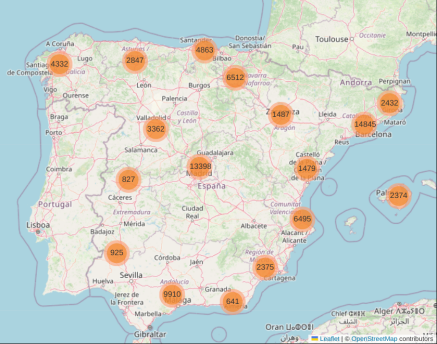

In [26]:
for item in COUNTRIES:

    if item not in ['US','DE']: # >100MB
        print(item)
    
        item_data = data.loc[data.country == item]
    
        map_fl = folium.Map(zoom_start=13, width=800, height=800)
        marker_cluster = MarkerCluster().add_to(map_fl)
        
        for itemA in tqdm(item_data.itertuples(), total=len(item_data), file=sys.stdout, ncols=100):
            folium.Marker(location=[itemA.lat,itemA.lon]).add_to(marker_cluster)
    
        map_fl.save(f'result-visual-maps/safeweb-{item}.html')  
    
# sample
#display(HTML(open(f'result-visual-maps/safeweb-{item}.html').read()))
print()
Image('result-visual-maps/safeweb-ES.png')

# Demo

In [27]:
# demo area
lat,lon = [48.158,11.552]
size = 50 #km

In [28]:
data['crd'] = gpd.points_from_xy(data.lon,data.lat)
data = gpd.GeoDataFrame(data)
data.crd = data.crd.set_crs('EPSG:4326')

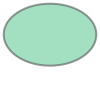

In [29]:
area = sh.Point(lon,lat)
area = gpd.GeoSeries(area).set_crs('EPSG:4326')
area = area.to_crs(area.estimate_utm_crs())
area = area.buffer(size*1000)
area = area.to_crs('EPSG:4326')
area.item()

In [30]:
data_area = data.loc[data.crd.within(area.item())]

data_area

,country,osm,lat,lon,tags,website,place_type,crd
909624,DE,node,48.0768836,11.5264376,"{'addr:city': 'München', 'addr:housenumber': '...",www.d-bug.net,Commerce,POINT (11.52644 48.07688)
1022363,DE,node,47.9906819,11.8643731,"{'addr:city': 'Glonn', 'addr:housenumber': '18...",glonn-feg.com,Facility,POINT (11.86437 47.99068)
759601,DE,node,48.1910511,11.8677012,"{'addr:city': 'Markt Schwaben', 'addr:country'...",www.cms-carsharing.de,Facility,POINT (11.86770 48.19105)
713528,DE,node,48.1037742,11.7691852,"{'bench': 'no', 'bin': 'no', 'bus': 'yes', 'ch...",www.mvv-muenchen.de,Facility,POINT (11.76919 48.10377)
701288,DE,node,47.9973091,11.171017,"{'addr:city': 'Herrsching am Ammersee', 'addr:...",www.arthotel-herrsching.de,Facility,POINT (11.17102 47.99731)
...,...,...,...,...,...,...,...,...
1196000,DE,way,48.1027366,11.5401548,"{'building': 'office', 'name': 'Isarwork', 'we...",www.terrafinanz.de,Unknown,POINT (11.54015 48.10274)
1008889,DE,node,48.3052834,11.9044483,"{'addr:city': 'Erding', 'addr:country': 'DE', ...",www.parisbarbershop.de,Commerce,POINT (11.90445 48.30528)
1060405,DE,way,48.1731731,11.8066918,"{'addr:housenumber': '2', 'addr:street': 'Gebr...",www.erzbistum-muenchen.de,Facility,POINT (11.80669 48.17317)
1006714,DE,node,48.2725691,11.583188,"{'addr:city': 'Unterschleißheim', 'addr:countr...",babybug.de,Commerce,POINT (11.58319 48.27257)


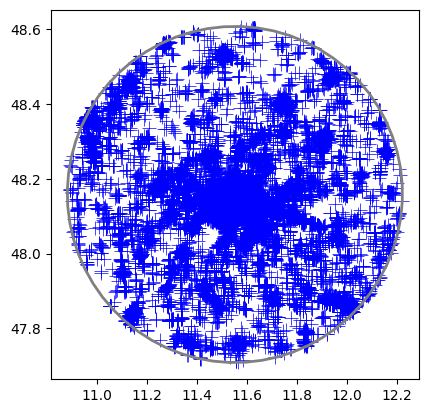

In [31]:
ax = area.boundary.plot(color='grey',lw = 2)
data_area.crd.plot(ax = ax,marker = '+', color = 'blue',markersize = 100,lw = 0.5)
plt.savefig(f'result-visual-maps/demo-map-area.png',bbox_inches='tight',pad_inches=0.01)

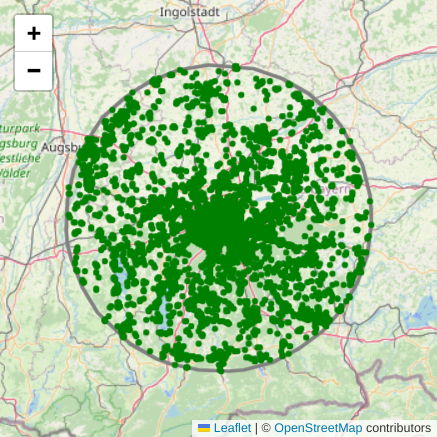

In [32]:
map_fl = folium.Map(location=[lat,lon],zoom_start=8,width=350,height=350)

crds = [(item[1], item[0]) for item in area.item().exterior.coords]
poly_fl = folium.Polygon(locations=crds,color='gray')
poly_fl.add_to(map_fl)

for item in data_area.loc[data_area.place_type == 'Facility'].itertuples():
    folium.CircleMarker(color='green',radius=1,
        location=[item.lat,item.lon],
        size=1).add_to(map_fl)    

map_fl.save('result-visual-maps/demo-map-facility.html')
#display(HTML(open('result-visual-maps/demo-map-facility.html').read()))
Image('result-visual-maps/demo-map-facility.png')

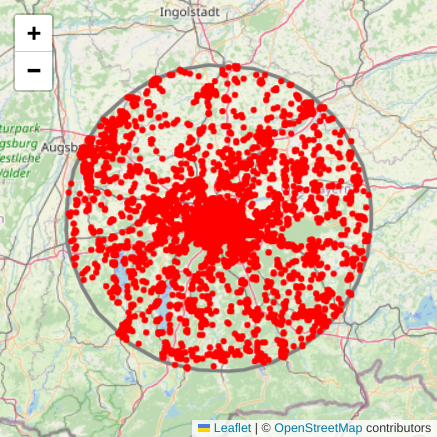

In [33]:
map_fl = folium.Map(location=[lat,lon],zoom_start=8,width=350,height=350)

crds = [(item[1], item[0]) for item in area.item().exterior.coords]
poly_fl = folium.Polygon(locations=crds,color='gray')
poly_fl.add_to(map_fl)   

for item in data_area.loc[data_area.place_type == 'Commerce'].itertuples():
    folium.CircleMarker(color='red',radius=1,
        location=[item.lat,item.lon],
        size=1).add_to(map_fl)

map_fl.save('result-visual-maps/demo-map-commerce.html')
#display(HTML(open('result-visual-maps/demo-map-commerce.html').read()))
Image('result-visual-maps/demo-map-commerce.png')

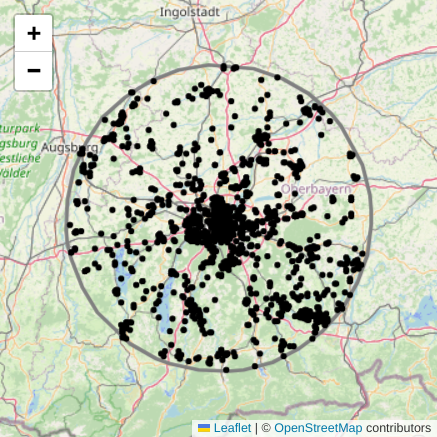

In [34]:
map_fl = folium.Map(location=[lat,lon],zoom_start=8,width=350,height=350)

crds = [(item[1], item[0]) for item in area.item().exterior.coords]
poly_fl = folium.Polygon(locations=crds,color='gray')
poly_fl.add_to(map_fl)   

for item in data_area.loc[data_area.place_type == 'Unknown'].itertuples():
    folium.CircleMarker(color='black',radius=1,
        location=[item.lat,item.lon],
        size=1).add_to(map_fl)

map_fl.save('result-visual-maps/demo-map-unknown.html')
#display(HTML(open('result-visual-maps/demo-map-unknown.html').read()))
Image('result-visual-maps/demo-map-unknown.png')

# Export

In [35]:
# clean data
todrop = data.loc[data.place_type == 'Forbidden']
print(len(todrop))
data = data.drop(todrop.index)

data.pop('tags');data.pop('osm');data.pop('crd');

6086


In [36]:
for item in COUNTRIES:
    item_data = data.loc[data.country == item]
    item_data.to_parquet(f'result-core-method/safeweb-{item}.parquet',index=False)
    item_data.to_csv(f'result-core-method/safeweb-{item}.csv',index=False)

frame_info(data)

,country,lat,lon,website,place_type
706743,DE,51.0639209,13.7484667,www.madebyrons.de,Commerce
2568445,US,59.6420498,-151.5577235,www.bidarkainn.com,Facility
...,...,...,...,...,...
2305984,US,42.7626012,-84.5005548,www.starbucks.com,Facility
1619900,JP,34.262904,135.109021,www.dreamsnet.com,Facility
